#Predicting Average Pit Stop Duration (Formula 1, 1950–2024)

### Presenters: Jim He & Brayden Gladman
### Date: February 19-22, 2026

## 1. Introduction

Formula 1 racing is a highly optimized, data-driven sport where race outcomes are influenced by strategic decisions made in real time. One of the most critical strategic components is the pit stop, during which a vehicle stops to change tires, make adjustments, or address mechanical issues. Even small variations in pit stop duration can significantly affect race position and overall performance.

This project applies machine learning techniques to analyze historical Formula 1 pit stop data from 1950 to 2024 in order to model, predict, and understand factors influencing pit stop duration during the race. Insights derived from this data driven modeling analysis could be use to inform racing strategy, performance optimization, and operational efficiency in realistic high-performance F1 environments.

The dataset we used in this project is the Formula 1 Pit Stop Dataset (1950–2024, all rounds), obtained from Kaggle @ https://www.kaggle.com/datasets/akashrane2609/formula-1-pit-stop-dataset named `Formula1_Pitstop_Data_1950-2024_all_rounds.csv`

The dataset aggregates historical pit stop records across all Formula 1 seasons and rounds, including:
- Season and round information
- Driver and constructor identifiers
- Pit stop number
- Lap number
- Pit stop duration (milliseconds/seconds)

## 2. Load Data & Preparation

### What one row represents
Each row in the CSV represents **one driver in one race** (driver-race pair).  
`AvgPitStopTime` is the average of that driver's pit stop times in that race (when available).  

We therefore treat this as a **race-level per-driver** prediction problem (target: average pit stop time per driver per race).

Rationale: the dataset also contains a `PitStops` column that is a list of stops; because that would leak per-stop details, we **drop** or avoid using raw `PitStops` entries in the conservative (pre-race) formulation below.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path('Formula1_Pitstop_Data_1950-2024_all_rounds.csv')
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nNon-null AvgPitStopTime count:", df['AvgPitStopTime'].notna().sum())
display(df.head(6))

Shape: (26759, 10)
Columns: ['Season', 'Round', 'Circuit', 'Driver', 'Constructor', 'Laps', 'Position', 'TotalPitStops', 'AvgPitStopTime', 'PitStops']

Non-null AvgPitStopTime count: 5575


,Season,Round,Circuit,Driver,Constructor,Laps,Position,TotalPitStops,AvgPitStopTime,PitStops
0,1950,1,Silverstone Circuit,Nino Farina,Alfa Romeo,70,1,0,NaN,[]
1,1950,1,Silverstone Circuit,Luigi Fagioli,Alfa Romeo,70,2,0,NaN,[]
2,1950,1,Silverstone Circuit,Reg Parnell,Alfa Romeo,70,3,0,NaN,[]
3,1950,1,Silverstone Circuit,Yves Cabantous,Talbot-Lago,68,4,0,NaN,[]
4,1950,1,Silverstone Circuit,Louis Rosier,Talbot-Lago,68,5,0,NaN,[]
5,1950,1,Silverstone Circuit,Bob Gerard,ERA,67,6,0,NaN,[]


## 3. Data Inspection and Clearing

In this part, we:
- Confirm column meanings and missingness.
- Inspect distribution of `AvgPitStopTime` and numeric features.
- Check cardinality of categorical variables (Driver, Constructor, Circuit).
- Identify columns that *could cause leakage* for the conservative problem formulation.

                  count unique                           top   freq  \
Season          26759.0    NaN                           NaN    NaN   
Round           26759.0    NaN                           NaN    NaN   
Circuit           26759     77  Autodromo Nazionale di Monza   1836   
Driver            26759    861               Fernando Alonso    404   
Constructor       26759    211                       Ferrari   2439   
Laps            26759.0    NaN                           NaN    NaN   
Position        26759.0    NaN                           NaN    NaN   
TotalPitStops   26759.0    NaN                           NaN    NaN   
AvgPitStopTime   5575.0    NaN                           NaN    NaN   
PitStops          26759   5568                            []  21184   

                       mean         std     min      25%     50%       75%  \
Season          1991.394372   19.952885  1950.0   1977.0  1991.0    2009.0   
Round              8.511192    5.070231     1.0      4.0     8

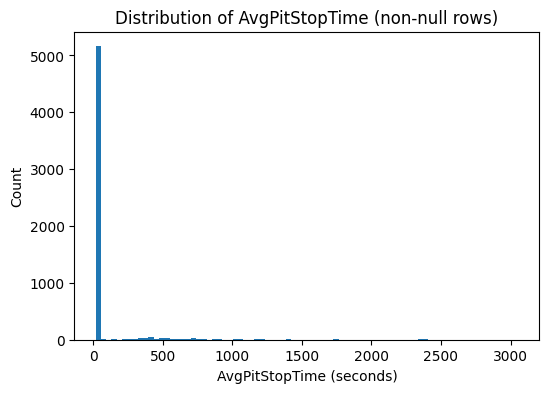

Season unique: 75
Circuit unique: 77
Driver unique: 861
Constructor unique: 211


In [ ]:
import matplotlib.pyplot as plt

# Basic stats
print(df.describe(include='all').transpose())

# Null counts
nulls = df.isnull().sum()
print("\nNull counts:\n", nulls)

# Distribution of the target (for non-null entries)
target = 'AvgPitStopTime'
target_nonnull = df[df[target].notnull()][target]
print("\nTarget stats (non-null):\n", target_nonnull.describe())

# Histogram (simple)
plt.figure(figsize=(6,4))
plt.hist(target_nonnull, bins=80)
plt.xlabel('AvgPitStopTime (seconds)')
plt.ylabel('Count')
plt.title('Distribution of AvgPitStopTime (non-null rows)')
plt.show()

# Cardinality
for c in ['Season','Circuit','Driver','Constructor']:
    print(f"{c} unique:", df[c].nunique())

## 4 — Problem Definition & Leakage Exclusion  

### Problem definition
**Task:** Predict `AvgPitStopTime` (seconds) for each *driver-race* row.

**Row definition:** each row = driver in a single race driver-race.

**Target:** `AvgPitStopTime` (the average of that driver's pit stop durations in that race).

**Leakage Exclusion:**
- Exclude fields derived from the *entire race* (e.g. `PitStops` raw list) when building a pre-race model.
- Exclude `TotalPitStops` in the main pipeline (optionally include in an exploratory 'post-race' model later).
- Use only features that would be available pre-race (season, circuit, driver, constructor, laps).

## 5. Preprocessing

1. Keep rows where `AvgPitStopTime` is present.

2. Filter to seasons up to 2022 for training; reserve 2023–2024 as holdout test (season-based split).

3. Build features:
   - `Season` (numeric)
   - `Laps` (numeric)
   - `Position` (numeric)
   - `Circuit` (categorical) — OneHot limited or frequency/target-encoded if needed
   - `Constructor` (categorical) — OneHot (top-k) with 'OTHER'
   - `Driver` (categorical) — top-k with 'OTHER' to avoid huge one-hot explosion
   
4. Standard scaling for numeric features when used with KNN/linear models.

In [ ]:
# Preprocessing code
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1) Drop rows without target
df_full = df[df['AvgPitStopTime'].notnull()].copy()
print("Supervised dataset rows:", df_full.shape[0])

# 2) seasonal split: train seasons <= 2022 ; test = 2023-2024
train_seasons = list(range(1950, 2023))  # up to 2022 inclusive
test_seasons = [2023, 2024]

train_df = df_full[df_full['Season'].isin(train_seasons)].copy()
test_df  = df_full[df_full['Season'].isin(test_seasons)].copy()
print("Train rows:", train_df.shape[0], "Test rows:", test_df.shape[0])

# 3) Feature list for the conservative model
FEATURES = ['Season', 'Laps', 'Position', 'Circuit', 'Constructor', 'Driver']
TARGET = 'AvgPitStopTime'

# Quick fill/cleanup: numeric NaNs -> median; categorical NaN -> 'UNKNOWN'
for col in ['Laps','Position']:
    if train_df[col].isnull().any():
        med = train_df[col].median()
        train_df[col].fillna(med, inplace=True)
        test_df[col].fillna(med, inplace=True)
for col in ['Circuit','Constructor','Driver']:
    train_df[col].fillna('UNKNOWN', inplace=True)
    test_df[col].fillna('UNKNOWN', inplace=True)

# Prepare top-k encoding for Driver and Constructor to limit cardinality
TOP_K_DRIVER = 50
TOP_K_CONSTRUCTOR = 20

top_drivers = train_df['Driver'].value_counts().nlargest(TOP_K_DRIVER).index.tolist()
top_constructors = train_df['Constructor'].value_counts().nlargest(TOP_K_CONSTRUCTOR).index.tolist()

def reduce_cardinality_series(s, top_list):
    return s.where(s.isin(top_list), other='OTHER')

train_df['Driver_top'] = reduce_cardinality_series(train_df['Driver'], top_drivers)
test_df['Driver_top']  = reduce_cardinality_series(test_df['Driver'], top_drivers)

train_df['Constructor_top'] = reduce_cardinality_series(train_df['Constructor'], top_constructors)
test_df['Constructor_top']  = reduce_cardinality_series(test_df['Constructor'], top_constructors)

FEATURES_FINAL = ['Season','Laps','Position','Circuit','Constructor_top','Driver_top']
print("Final feature set:", FEATURES_FINAL)

Supervised dataset rows: 5575
Train rows: 4701 Test rows: 874
Final feature set: ['Season', 'Laps', 'Position', 'Circuit', 'Constructor_top', 'Driver_top']


/tmp/ipython-input-3464370576.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna('UNKNOWN', inplace=True)
/tmp/ipython-input-3464370576.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

## 6. Baselines (naive) + evaluation helpers (code)

Baselines:
- Global mean predictor (predict the mean `AvgPitStopTime` from training set).
- Group mean predictor by `(Constructor, Season)` or `(Constructor)` (a simple domain-aware baseline as suggested in feedback).

Evaluation metrics:
MAE, RMSE, R².
We will use GroupKFold (group = Season) for cross-validation on the training seasons to avoid season leakage during CV.

In [ ]:
# Baselines & evaluation helpers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Baseline 1: global mean
global_mean = train_df[TARGET].mean()
print("Global mean baseline:", global_mean)

# Baseline 2: constructor-season mean (falls back to constructor mean -> global mean)
cs_mean = train_df.groupby(['Constructor_top','Season'])[TARGET].mean()
c_mean = train_df.groupby(['Constructor_top'])[TARGET].mean()

def predict_baseline_constructor_season(df_):
    preds = []
    for _, row in df_.iterrows():
        key = (row['Constructor_top'], row['Season'])
        if key in cs_mean:
            preds.append(cs_mean.loc[key])
        elif row['Constructor_top'] in c_mean:
            preds.append(c_mean.loc[row['Constructor_top']])
        else:
            preds.append(global_mean)
    return np.array(preds)

# Evaluate baselines on test set
y_test = test_df[TARGET].values
pred_global = np.full_like(y_test, global_mean, dtype=float)
pred_cs = predict_baseline_constructor_season(test_df)

print("Global baseline (test):", eval_metrics(y_test, pred_global))
print("Constructor-season baseline (test):", eval_metrics(y_test, pred_cs))

Global mean baseline: 60.74643441820885
Global baseline (test): {'MAE': 132.8910482323928, 'RMSE': np.float64(342.78592952737154), 'R2': -0.04497976387517255}
Constructor-season baseline (test): {'MAE': 146.7243712272678, 'RMSE': np.float64(341.1773240940488), 'R2': -0.03519513839000887}


## 7. Model Pipelines & Grouped Cross-validation

Models:
- Regularized linear model (Ridge) in a pipeline with OneHot for categorical small-cardinality features and StandardScaler for numerics.
- K-Nearest Neighbors regressor.
- RandomForest regressor (tree-based).

Cross-Validation:
- GroupKFold with groups=Season on training set (n_splits=5).
- We'll use this for hyperparameter search (GridSearchCV with GroupKFold).

In [ ]:
# Modeling pipelines & CV setup
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold

numeric_features = ['Season','Laps','Position']
categorical_features = ['Circuit','Constructor_top','Driver_top']

# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
], remainder='drop')

# Pipelines for 3 model types
pipe_ridge = Pipeline([('pre', preprocessor), ('model', Ridge())])
pipe_knn   = Pipeline([('pre', preprocessor), ('model', KNeighborsRegressor())])
pipe_rf    = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])

# Parameter grids
param_ridge = {'model__alpha': [0.1, 1.0, 10.0]}
param_knn = {'model__n_neighbors': [3,5,8], 'model__weights': ['uniform','distance']}
param_rf = {'model__n_estimators': [100, 200], 'model__max_depth': [None, 10, 20]}

# Grouped CV
groups = train_df['Season']
gkf = GroupKFold(n_splits=5)

In [ ]:
# Grid search helper (fit on training seasons only)
def run_grid_search(pipeline, param_grid, X, y, groups, cv):
    gs = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    gs.fit(X, y, groups=groups)
    return gs

X_train = train_df[FEATURES_FINAL]
y_train = train_df[TARGET].values
X_test  = test_df[FEATURES_FINAL]
y_test  = test_df[TARGET].values

# Fit three models (this may take time)
print("Running Ridge GridSearch...")
gs_ridge = run_grid_search(pipe_ridge, param_ridge, X_train, y_train, groups, gkf)
print("Best Ridge params:", gs_ridge.best_params_)

print("Running KNN GridSearch...")
gs_knn = run_grid_search(pipe_knn, param_knn, X_train, y_train, groups, gkf)
print("Best KNN params:", gs_knn.best_params_)

print("Running RF GridSearch...")
gs_rf = run_grid_search(pipe_rf, param_rf, X_train, y_train, groups, gkf)
print("Best RF params:", gs_rf.best_params_)

Running Ridge GridSearch...
Best Ridge params: {'model__alpha': 10.0}
Running KNN GridSearch...
Best KNN params: {'model__n_neighbors': 3, 'model__weights': 'distance'}
Running RF GridSearch...
Best RF params: {'model__max_depth': 20, 'model__n_estimators': 100}


## 8. Evaluation & Model Comparison

We evaluate the best estimator from each grid on the hold-out test seasons (2023–2024) using MAE, RMSE, R².

In [ ]:
# Evaluate best models on test set
models = {
    'Ridge': gs_ridge.best_estimator_,
    'KNN': gs_knn.best_estimator_,
    'RandomForest': gs_rf.best_estimator_
}

results = {}
for name, model in models.items():
    preds = model.predict(X_test)
    results[name] = eval_metrics(y_test, preds)
    print(name, results[name])

# Include baselines for reference
results['GlobalMean'] = eval_metrics(y_test, pred_global)
results['ConstructorSeasonBaseline'] = eval_metrics(y_test, pred_cs)

# Tabulate results
import pandas as pd
res_df = pd.DataFrame(results).T
display(res_df)

Ridge {'MAE': 181.75551125084937, 'RMSE': np.float64(342.49954993401104), 'R2': -0.04323444211177474}
KNN {'MAE': 181.7142757463194, 'RMSE': np.float64(392.380557909332), 'R2': -0.36923145392756695}
RandomForest {'MAE': 155.00948553744334, 'RMSE': np.float64(398.6882703680995), 'R2': -0.41360744501428237}


,MAE,RMSE,R2
Ridge,181.755511,342.499550,-0.043234
KNN,181.714276,392.380558,-0.369231
RandomForest,155.009486,398.688270,-0.413607
GlobalMean,132.891048,342.785930,-0.044980
ConstructorSeasonBaseline,146.724371,341.177324,-0.035195


## 9. Interpretability (Features Importance)

- For linear models, we can inspect coefficients.

- For RandomForest, we inspect feature importances (mapped back from OneHot to original categorical features aggregated).


In [ ]:
# Feature importances for RF
# Need to map OneHot columns back to original names
ohe = models['RandomForest'].named_steps['pre'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_features)
num_feature_names = numeric_features
full_feature_names = np.concatenate([num_feature_names, ohe_feature_names])

rf_model = models['RandomForest'].named_steps['model']
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=full_feature_names).sort_values(ascending=False).head(25)
display(feat_imp)

# Coefficients for Ridge
ridge_model = models['Ridge'].named_steps['model']
coeffs = pd.Series(ridge_model.coef_, index=full_feature_names).sort_values(ascending=False).head(25)
display(coeffs)

,0
Season,0.521438
Circuit_Silverstone Circuit,0.112226
Laps,0.076874
Position,0.042583
Circuit_Jeddah Corniche Circuit,0.037055
Circuit_Baku City Circuit,0.019041
Circuit_Autodromo Internazionale del Mugello,0.018486
Circuit_Autodromo Nazionale di Monza,0.017568
Circuit_AutÃ³dromo JosÃ© Carlos Pace,0.017562
Circuit_Suzuka Circuit,0.012021


,0
Circuit_Jeddah Corniche Circuit,241.399016
Circuit_Autodromo Internazionale del Mugello,231.924853
Circuit_Silverstone Circuit,101.163820
Circuit_Autodromo Enzo e Dino Ferrari,74.620074
Circuit_AutÃ³dromo JosÃ© Carlos Pace,71.973949
Circuit_Baku City Circuit,66.014378
Driver_top_Felipe Nasr,51.731026
Constructor_top_AlphaTauri,41.126293
Driver_top_Nicholas Latifi,39.542815
Driver_top_Nico Rosberg,28.324389


## 10. Summary and Conclusion

### Models Performance Evaluation vs Baseline
Ridge: MAE = 181.76, RMSE = 342.50, R² = -0.043

KNN: MAE = 181.71, RMSE = 392.38, R² = -0.369

RandomForest: MAE = 155.01, RMSE = 398.69, R² = -0.414

Global mean baseline: MAE = 132.89, RMSE = 342.79, R² = -0.045

Constructor-season baseline: MAE = 146.72, RMSE = 341.18, R² = -0.035

### Conclusion

All three trained models produce negative R² on the hold-out, which means they explain less variance than predicting the (training) mean. In other words, the models as trained underperform a simple global-mean baseline (and in MAE terms, also underperform the constructor-season baseline).

Among the three, RandomForest achieves the lowest MAE (155.0), but its RMSE and R² are worse than Ridge and KNN — indicating that although RF reduces average absolute error a bit, it produces very large errors on some cases (outliers), which inflates RMSE and drags R² down.

Ridge is the least-bad relative to the mean baseline in R² (closest to zero). That suggests the signal captured by simple linear regularized features is about as informative as the dataset allows under this pipeline.


### Interpretation
The model/importance outputs show season and circuit identity dominate predictive power. For example, the largest importance mass is on Season and circuits such as Silverstone Circuit, Jeddah Corniche Circuit, and Autodromo Internazionale del Mugello.

Numeric race-level fields like Laps and Position contribute, but substantially less than circuit/season indicators.

A few drivers and constructors (for example, Felipe Nasr, Esteban Ocon, Red Bull, and Ferrari) appear among important features but their impact is noticeably smaller than the circuit/season signal.
